In [59]:
import argparse
import numpy as np

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

In [60]:
# ============================================================================
# 1. CIRCUIT BUILDERS  (backend-agnostic -- no dynamic circuits)
# ============================================================================



def honest_teleport_circuit(bit, sign_basis="X"):
    """One honest QDS teleportation round as a static circuit.

    q0 = Alice's message qubit (prepared in the signing basis to encode `bit`)
    q1 = Alice's half of the EPR pair
    q2 = Bob's half of the EPR pair (the qubit that ends up carrying the message)

    Alice Bell-measures (q0,q1) -> classical bits (m0,m1). Bob's qubit q2 then
    holds the message up to a Pauli X^{m1} Z^{m0} that we undo CLASSICALLY in
    post-processing (deferred correction). Bob measures q2 in the signing basis.

    Returns the circuit; the bit `bit` and `sign_basis` are what the verifier
    checks the corrected outcome against.
    """
    q = QuantumRegister(3, "q")
    c = ClassicalRegister(3, "c")   # c[0]=m0 (Alice Z-part), c[1]=m1 (Alice X-part), c[2]=Bob
    qc = QuantumCircuit(q, c)

    # --- Alice encodes `bit` in the public signing basis on q0 ---
    if bit == 1:
        qc.x(q[0])
    if sign_basis == "X":
        qc.h(q[0])

    # --- create EPR pair on (q1,q2): the controlled-EPR channel ---
    qc.h(q[1])
    qc.cx(q[1], q[2])

    qc.barrier()

    # --- Alice's Bell measurement on (q0,q1) = un-compute Bell pair, measure Z ---
    qc.cx(q[0], q[1])
    qc.h(q[0])
    qc.measure(q[0], c[0])          # m0  -> governs a Z correction on Bob
    qc.measure(q[1], c[1])          # m1  -> governs an X correction on Bob

    qc.barrier()

    # --- Bob measures his qubit in the signing basis (correction deferred) ---
    if sign_basis == "X":
        qc.h(q[2])
    qc.measure(q[2], c[2])
    return qc


In [61]:
def intercept_resend_teleport_circuit(bit, sign_basis="X", eve_x=False):
    """Same honest round, but Eve intercept-resends Bob's travelling qubit q2:
    she measures it in basis `eve_x` (False=Z, True=X), then resends a fresh
    qubit in the state she found. Implemented as a mid-circuit
    measure+reset+re-prepare on q2 -- measure/reset/if_test are the only dynamic
    ops used, and re-preparation is conditional on Eve's own stolen bit, which
    is allowed on any backend supporting basic feedforward.

    IMPORTANT: a real intercept-resend attacker picks her basis at RANDOM each
    round. A single fixed basis does NOT fully break the correlations, so the
    caller must run BOTH eve_x=False and eve_x=True and average the results
    50/50 (see run_intercept_demo / run_chsh). Averaging over the two bases is
    what reproduces the textbook collapse (mismatch ~0.5, CHSH ~1.41)."""
    q = QuantumRegister(3, "q")
    c = ClassicalRegister(3, "c")
    ce = ClassicalRegister(1, "eve")   # Eve's stolen outcome (not used by verifier)
    qc = QuantumCircuit(q, c, ce)

    if bit == 1:
        qc.x(q[0])
    if sign_basis == "X":
        qc.h(q[0])
    qc.h(q[1])
    qc.cx(q[1], q[2])
    qc.barrier()

    # --- Eve taps q2 in basis `eve_x`, measures, resends what she saw ---
    if eve_x:
        qc.h(q[2])
    qc.measure(q[2], ce[0])
    qc.reset(q[2])
    with qc.if_test((ce[0], 1)):
        qc.x(q[2])
    if eve_x:
        qc.h(q[2])
    qc.barrier()

    qc.cx(q[0], q[1])
    qc.h(q[0])
    qc.measure(q[0], c[0])
    qc.measure(q[1], c[1])
    qc.barrier()
    if sign_basis == "X":
        qc.h(q[2])
    qc.measure(q[2], c[2])
    return qc

In [62]:
def chsh_circuits(alice_angle, bob_angle):
    """One CHSH correlation circuit: a genuine Bell pair on (q0,q1), Alice
    measures q0 at `alice_angle`, Bob measures q1 at `bob_angle`. Returns a
    static circuit measuring both in Z after a basis rotation."""
    qc = QuantumCircuit(2, 2)
    qc.h(0)
    qc.cx(0, 1)
    qc.barrier()
    # rotate each qubit so a Z-measurement realises the M(theta)=cosθ Z+sinθ X obs
    qc.ry(-2 * alice_angle, 0)
    qc.ry(-2 * bob_angle, 1)
    qc.measure(0, 0)
    qc.measure(1, 1)
    return qc

In [63]:
def chsh_intercepted_circuits(alice_angle, bob_angle, eve_x=False):
    """CHSH on a pair Eve intercept-resends in basis `eve_x` -> entanglement
    destroyed, S drops below 2 once averaged over BOTH Eve bases (the caller
    must run eve_x=False and eve_x=True 50/50; a single fixed basis leaves
    residual correlation). Registers: c=(c0,c1) measurement, ev=Eve's bit."""
    q = QuantumRegister(2, "q")
    c = ClassicalRegister(2, "c")
    ev = ClassicalRegister(1, "ev")
    qc = QuantumCircuit(q, c, ev)
    qc.h(0)
    qc.cx(0, 1)
    qc.barrier()
    if eve_x:
        qc.h(1)
    qc.measure(1, ev[0])
    qc.reset(1)
    with qc.if_test((ev[0], 1)):
        qc.x(1)
    if eve_x:
        qc.h(1)
    qc.barrier()
    qc.ry(-2 * alice_angle, 0)
    qc.ry(-2 * bob_angle, 1)
    qc.measure(0, c[0])
    qc.measure(1, c[1])
    return qc

In [64]:
# ============================================================================
# 2. CLASSICAL POST-PROCESSING  (the deferred teleportation correction)
# ============================================================================


def verify_counts(counts, expected_bit):
    """Given SamplerV2 counts over the 3-bit register c (c0=m0,c1=m1,c2=Bob),
    apply the deferred teleportation correction classically and return the
    mismatch rate vs `expected_bit`.

    Deferred correction (derived empirically and confirmed at zero noise):
    Bob signs in the X basis, so his +/- outcome is flipped by a Z on his qubit,
    and the Z-part of the teleportation correction is governed by Alice's m0.
    (The X-part m1 would flip a Z-basis outcome, not an X-basis one.) Hence
    corrected_bit = b XOR m0.
    """
    total = 0
    bad = 0
    for bitstr, n in counts.items():
        # Qiskit bitstrings are little-endian & space-separated per register;
        # normalise to a flat string of the c-register (ignore Eve reg if present)
        flat = bitstr.replace(" ", "")
        # c register is the LAST 3 classical bits defined -> take rightmost 3,
        # but Eve's extra reg (if any) was defined AFTER c, so it's leftmost.
        # Simplest robust approach: the c-register bits are the last 3 chars.
        creg = flat[-3:]
        m0 = int(creg[-1])   # c[0]  Z-part
        m1 = int(creg[-2])   # c[1]  X-part
        b = int(creg[-3])    # c[2]  Bob
        corrected = b ^ m0
        total += n
        if corrected != expected_bit:
            bad += n
    return bad / max(total, 1)



In [65]:
def chsh_value_from_counts(count_sets):
    """count_sets: dict keyed by (setting_a, setting_b) in {0,1}^2, each a counts
    dict over 2 classical bits. Returns CHSH S."""
    def E(counts):
        tot = same = 0
        for bitstr, n in counts.items():
            flat = bitstr.replace(" ", "")
            a = int(flat[-1]); b = int(flat[-2])
            tot += n
            same += n if a == b else 0
        # correlation = P(equal) - P(different)
        return (2 * same - tot) / max(tot, 1)
    E00 = E(count_sets[(0, 0)])
    E01 = E(count_sets[(0, 1)])
    E10 = E(count_sets[(1, 0)])
    E11 = E(count_sets[(1, 1)])
    return E00 + E01 + E10 - E11

In [66]:
# ============================================================================
# 3. BACKEND / SAMPLER PLUMBING  (one switch for sim vs hardware)
# ============================================================================

def get_sampler_and_pm(mode, backend_name=None, shots=2048):
    """Return (run_fn, pass_manager, label). run_fn(list_of_circuits) -> list of
    counts dicts. The SAME circuits go through whichever path this returns."""
    from qiskit_aer import AerSimulator

    if mode == "sim":
        backend = AerSimulator()
        pm = generate_preset_pass_manager(backend=backend, optimization_level=1)

        def run_fn(circs):
            isa = pm.run(circs)
            res = backend.run(isa, shots=shots).result()
            return [res.get_counts(i) for i in range(len(circs))]
        return run_fn, pm, "AerSimulator (noiseless)"

    if mode == "sim-noisy":
        # download a real backend's calibration -> build a noise model -> simulate
        from qiskit_ibm_runtime import QiskitRuntimeService
        from qiskit_aer.noise import NoiseModel
        service = QiskitRuntimeService()
        real = (service.backend(backend_name) if backend_name
                else service.least_busy(operational=True, simulator=False))
        noise_model = NoiseModel.from_backend(real)
        backend = AerSimulator(noise_model=noise_model)
        pm = generate_preset_pass_manager(backend=real, optimization_level=1)

        def run_fn(circs):
            isa = pm.run(circs)
            res = backend.run(isa, shots=shots).result()
            return [res.get_counts(i) for i in range(len(circs))]
        return run_fn, pm, f"AerSimulator + from_backend({real.name}) noise"

    if mode == "hw":
        from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
        service = QiskitRuntimeService()
        backend = (service.backend(backend_name) if backend_name
                   else service.least_busy(operational=True, simulator=False))
        pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
        sampler = Sampler(mode=backend)

        def run_fn(circs):
            isa = pm.run(circs)
            job = sampler.run(isa, shots=shots)
            result = job.result()
            counts = []
            for i in range(len(circs)):
                # SamplerV2: pick the classical register named 'c' if present,
                # else the default. get_counts() joins all cregs.
                data = result[i].data
                # take the register that holds the signing measurement
                reg = getattr(data, "c", None)
                counts.append(reg.get_counts() if reg is not None
                              else next(iter(vars(data).values())).get_counts())
            return counts
        return run_fn, pm, f"IBM QPU: {backend.name}"

    raise ValueError(mode)

In [67]:
# ============================================================================
# 4. DRIVERS
# ============================================================================

def run_honest_calibration(run_fn, n_rounds=200, seed=42):
    """Build n honest rounds (random bits), run them, return the mismatch rate
    p0_hat -> tau = p0_hat + margin. On hardware keep n_rounds small."""
    rng = np.random.default_rng(seed)
    circs, bits = [], []
    for _ in range(n_rounds):
        b = int(rng.integers(0, 2))
        circs.append(honest_teleport_circuit(b, sign_basis="X"))
        bits.append(b)
    # 1 shot per circuit == 1 signing round; batch as many shots as cheap on sim
    counts_list = run_fn(circs)
    mism = np.mean([verify_counts(cnts, bits[i]) for i, cnts in enumerate(counts_list)])
    return mism

In [68]:
def run_intercept_demo(run_fn, n_rounds=200, seed=7):
    """Half the rounds with Eve in Z, half in X (a real attacker randomises her
    basis); average the mismatch. Fixing one basis would understate the damage."""
    rng = np.random.default_rng(seed)
    circs, bits = [], []
    for i in range(n_rounds):
        b = int(rng.integers(0, 2))
        eve_x = (i % 2 == 1)
        circs.append(intercept_resend_teleport_circuit(b, "X", eve_x))
        bits.append(b)
    counts_list = run_fn(circs)
    return np.mean([verify_counts(c, bits[i]) for i, c in enumerate(counts_list)])

In [69]:
def run_chsh(run_fn, intercepted=False):
    """Optimal CHSH angles: Alice {0, pi/4}, Bob {pi/8, -pi/8} -> S=2*sqrt2 for a
    genuine pair. For the intercepted case, each setting is run in BOTH of Eve's
    bases and averaged 50/50, which is what collapses S to ~1.41."""
    a_ang = {0: 0.0, 1: np.pi / 4}
    b_ang = {0: np.pi / 8, 1: -np.pi / 8}
    settings = [(0, 0), (0, 1), (1, 0), (1, 1)]

    if not intercepted:
        circs = [chsh_circuits(a_ang[sa], b_ang[sb]) for (sa, sb) in settings]
        counts_list = run_fn(circs)
        return chsh_value_from_counts({settings[i]: counts_list[i] for i in range(4)})

    # intercepted: build 8 circuits (4 settings x 2 Eve bases), average per setting
    circs = []
    for (sa, sb) in settings:
        for eve_x in (False, True):
            circs.append(chsh_intercepted_circuits(a_ang[sa], b_ang[sb], eve_x))
    counts_list = run_fn(circs)
    merged = {}
    for idx, (sa, sb) in enumerate(settings):
        cz = counts_list[2 * idx]        # Eve Z
        cx = counts_list[2 * idx + 1]    # Eve X
        merged[(sa, sb)] = _merge_counts(cz, cx)
    return chsh_value_from_counts(merged)

In [70]:
def _merge_counts(*count_dicts):
    """Combine several counts dicts (equal-weight) into one, for basis-averaging."""
    out = {}
    for cd in count_dicts:
        for k, v in cd.items():
            out[k] = out.get(k, 0) + v
    return out


In [71]:
def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--mode", choices=["sim", "sim-noisy", "hw"], default="sim")
    ap.add_argument("--backend", default=None)
    ap.add_argument("--shots", type=int, default=2048)
    ap.add_argument("--rounds", type=int, default=200,
                    help="honest/attack rounds; keep small (<=64) on hw")
    # Jupyter passes its own --f=... kernel args which argparse rejects.
    # parse_known_args() silently ignores anything it doesn't recognise,
    # so the code works unchanged whether run as a script or a notebook cell.
    args, _ = ap.parse_known_args()
 
    run_fn, pm, label = get_sampler_and_pm(args.mode, args.backend, args.shots)
    print(f"[backend] {label}   shots={args.shots}  rounds={args.rounds}\n")
 
    # 1. honest calibration -> tau
    p0 = run_honest_calibration(run_fn, n_rounds=args.rounds)
    tau = p0 + 0.10
    print(f"[honest]     p0_hat = {p0:.3f}   -> tau = {tau:.3f}")
 
    # 2. CHSH witness, genuine vs intercepted
    s_good = run_chsh(run_fn, intercepted=False)
    print(f"[CHSH]       genuine pair      S = {s_good:.3f}   "
          f"({'violates' if s_good > 2 else 'does NOT violate'} classical bound)")
    if args.mode != "hw":   # save qpu time: only run the extra intercepted CHSH off-hardware
        s_bad = run_chsh(run_fn, intercepted=True)
        print(f"[CHSH]       intercepted pair  S = {s_bad:.3f}   "
              f"({'still violates' if s_bad > 2 else 'collapsed below 2'})")
 
    # 3. intercept-resend attack -> elevated mismatch
    p_att = run_intercept_demo(run_fn, n_rounds=args.rounds)
    verdict = "REJECT" if p_att > tau else "accept"
    print(f"[intercept]  p_hat  = {p_att:.3f}   -> {verdict}")
 
    print("\nDone. For hardware: --mode hw --shots 1024 --rounds 32   "
          "(and log backend.name + backend.properties().last_update_date).")
 
 
if __name__ == "__main__":
    main()

[backend] AerSimulator (noiseless)   shots=2048  rounds=200

[honest]     p0_hat = 0.000   -> tau = 0.100
[CHSH]       genuine pair      S = 2.832   (violates classical bound)
[CHSH]       intercepted pair  S = 1.425   (collapsed below 2)
[intercept]  p_hat  = 0.250   -> REJECT

Done. For hardware: --mode hw --shots 1024 --rounds 32   (and log backend.name + backend.properties().last_update_date).


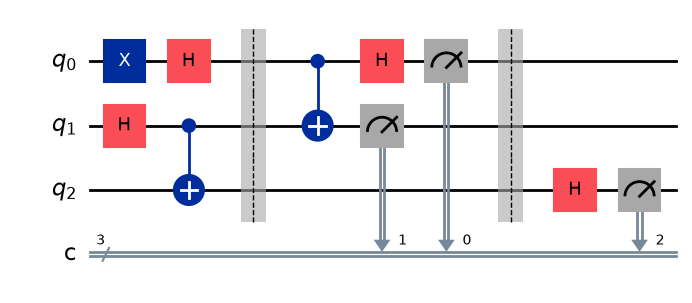

In [ ]:
# deferred-correction version (what actually runs)
#qc_deferred = honest_teleport_circuit(bit=1, sign_basis="X")
#qc_deferred.draw('mpl', style='iqp')
# feedforward version (for the writeup figure)
# first uncomment the function at the bottom of qds_qiskit.py

#qc_ff = honest_teleport_feedforward(bit=1, sign_basis="X")
#qc_ff.draw('mpl', style='iqp')

In [79]:
# ============================================================================
# APPENDIX -- literal feed-forward teleportation (dynamic circuit), for a figure
# ----------------------------------------------------------------------------
# Only runs on backends where "dynamic_circuits" in
# backend.configuration().supported_features is True. Kept out of the main path
# so the demo never fails on a backend that lacks feedforward support.
#
def honest_teleport_feedforward(bit, sign_basis="X"):
     q = QuantumRegister(3, "q"); c = ClassicalRegister(3, "c")
     qc = QuantumCircuit(q, c)
     if bit == 1: qc.x(q[0])
     if sign_basis == "X": qc.h(q[0])
     qc.h(q[1]); qc.cx(q[1], q[2])
     qc.cx(q[0], q[1]); qc.h(q[0])
     qc.measure(q[0], c[0]); qc.measure(q[1], c[1])
     with qc.if_test((c[1], 1)): qc.x(q[2])   # X correction
     with qc.if_test((c[0], 1)): qc.z(q[2])   # Z correction
     if sign_basis == "X": qc.h(q[2])
     qc.measure(q[2], c[2])
     return qc
# ============================================================================


In [73]:
# ============================================================================
# 5. RESULTS EMITTER  --  dumps a results.json the dashboard reads
# ============================================================================

def emit_results_json(path="results.json", mode="sim", backend_name=None,
                      shots=2048, rounds=200):
    """Run the calibration + CHSH + intercept demo through whichever backend
    `mode` selects, and also pull the full attack sweep from the NumPy detector
    (qds_unified) so the dashboard shows every scenario. Writes a single JSON.

    The circuit-level numbers (honest p0, CHSH genuine/intercepted, intercept
    mismatch) come from Qiskit; the remaining transcript-level attacks (forgery,
    splice, impersonation, replay, ancilla decoys) come from the validated NumPy
    engine, since those never touch a live channel and don't need circuits.
    """
    import json
    import datetime as _dt

    run_fn, _pm, label = get_sampler_and_pm(mode, backend_name, shots)

    # --- circuit-derived numbers ---
    p0 = run_honest_calibration(run_fn, n_rounds=rounds)
    tau = round(p0 + 0.10, 4)
    s_good = run_chsh(run_fn, intercepted=False)
    s_bad = run_chsh(run_fn, intercepted=True)
    p_int = run_intercept_demo(run_fn, n_rounds=rounds)

    # --- transcript-level sweep from the validated NumPy detector ---
    import numpy as _np
    try:
        import qds_unified as U
        rng = _np.random.default_rng(42)
        N = 2000
        P0 = max(p0, 0.001)
        # honest baseline for the NumPy side (kept separate; circuit p0 is the headline)
        fb = U.attack_forgery_blind(N, rng)
        im = U.attack_impersonation(N, rng)
        rp = U.attack_replay(N, rng, noise_p0=P0)
        ca = U.attack_channel(N, rng, kind='ancilla', noise_p0=P0)
        msg = list(rng.integers(0, 2, size=12))
        good = U.encode_with_boundary(msg)
        spliced = U.attack_forgery_splice(good, slice(6, 15))
        anc_x, anc_z = U.decoy_error_rates('ancilla', rng)
        transcript = {
            "forgery_blind": dict(p_hat=round(U.mismatch_rate(fb), 3),
                                  decoy_x=0.0, decoy_z=0.0, chsh=round(s_good, 3),
                                  verdict="reject",
                                  label="Classical-transcript \u2192 forgery"),
            "forgery_splice": dict(p_hat=0.0, decoy_x=0.0, decoy_z=0.0,
                                   chsh=round(s_good, 3),
                                   verdict="reject",
                                   label="Passes per-round check; boundary check FAILS",
                                   boundary_full=U.verify_boundary(good),
                                   boundary_spliced=U.verify_boundary(spliced)),
            "impersonation": dict(p_hat=round(U.mismatch_rate(im), 3),
                                  decoy_x=0.0, decoy_z=0.0, chsh=round(s_good, 3),
                                  verdict="reject",
                                  label="Classical-transcript \u2192 impersonation"),
            "replay": dict(p_hat=round(U.mismatch_rate(rp), 3),
                           decoy_x=0.0, decoy_z=0.0, chsh=round(s_good, 3),
                           verdict="reject",
                           label="Classical-transcript \u2192 replay (cross-round key mismatch)"),
            "channel_ancilla": dict(p_hat=round(U.mismatch_rate(ca), 3),
                                    decoy_x=round(anc_x, 3), decoy_z=round(anc_z, 3),
                                    chsh=round(s_good, 3),
                                    verdict="reject",
                                    label="Channel \u2192 entangle-ancilla (X-only, Z-clean stealth tap)"),
        }
    except Exception as e:
        transcript = {"_note": f"NumPy sweep unavailable: {e}"}

    data = {
        "meta": {
            "backend": label,
            "backend_name": backend_name or label,
            "mode": mode,
            "shots": shots,
            "rounds": rounds,
            "generated_utc": _dt.datetime.utcnow().isoformat(timespec="seconds") + "Z",
        },
        "calibration": {
            "p0": round(p0, 4),
            "tau": tau,
            "margin": 0.10,
        },
        "chsh": {
            "genuine": round(s_good, 3),
            "intercepted": round(s_bad, 3),
            "classical_bound": 2.0,
            "quantum_max": round(2 * 2 ** 0.5, 3),
        },
        "scenarios": {
            "honest": dict(p_hat=round(p0, 3), decoy_x=0.0, decoy_z=0.0,
                           chsh=round(s_good, 3), verdict="accept",
                           label="Legitimate"),
            "channel_intercept": dict(p_hat=round(p_int, 3),
                                      decoy_x=round(p_int, 3), decoy_z=round(p_int, 3),
                                      chsh=round(s_bad, 3), verdict="reject",
                                      label="Channel \u2192 intercept-resend (CHSH collapsed)"),
            **transcript,
        },
    }

    with open(path, "w") as f:
        json.dump(data, f, indent=2)
    print(f"[emit] wrote {path}  (backend: {label})")
    return data


In [74]:
def _cli_emit():
    ap = argparse.ArgumentParser()
    ap.add_argument("--mode", choices=["sim", "sim-noisy", "hw"], default="sim")
    ap.add_argument("--backend", default=None)
    ap.add_argument("--shots", type=int, default=2048)
    ap.add_argument("--rounds", type=int, default=200)
    ap.add_argument("--out", default="results.json")
    args = ap.parse_args()
    emit_results_json(args.out, args.mode, args.backend, args.shots, args.rounds)
